## 1. Environment Setup

In [56]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, classification_report
)
import joblib

# XGBoost
import xgboost as xgb

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Paths - UPDATED TO NEW DATASET
DATA_PATH = 'preprocessed_data/timestamped_predictive_maintenance_timeseries_NEW.csv'
ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)

# Feature configuration
NUMERICAL_FEATURES = [
    'air_temperature_K',
    'process_temperature_K',
    'rotational_speed_rpm',
    'torque_Nm',
    'tool_wear_min'
]
SEQUENCE_LENGTH = 50  # Timesteps per sequence

# AC-02 Performance Targets
TARGET_RECALL = 0.70
TARGET_ACCURACY = 0.70

print("✓ Environment configured")
print(f"  Dataset: {DATA_PATH}")
print(f"  Random seed: {RANDOM_SEED}")
print(f"  Artifacts directory: {ARTIFACTS_DIR}")
print(f"  Sequence length: {SEQUENCE_LENGTH}")

✓ Environment configured
  Dataset: preprocessed_data/timestamped_predictive_maintenance_timeseries_NEW.csv
  Random seed: 42
  Artifacts directory: artifacts
  Sequence length: 50


## 2. Data Loading & Validation

In [57]:
# Load synthetic time-series dataset
df = pd.read_csv(DATA_PATH)

# Basic validation
print("Dataset Information:")
print(f"  Total samples: {len(df):,}")
print(f"  Unique machines: {df['product_id'].nunique():,}")
print(f"  Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"  Columns: {list(df.columns)}")

# Check for required columns
required_cols = ['product_id', 'timestamp', 'is_failure', 'synthetic_RUL'] + NUMERICAL_FEATURES
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Encode categorical feature if needed
if 'engine_type' in df.columns and 'engine_type_encoded' not in df.columns:
    engine_encoder = LabelEncoder()
    df['engine_type_encoded'] = engine_encoder.fit_transform(df['engine_type'])
    joblib.dump(engine_encoder, ARTIFACTS_DIR / 'encoder_engine_type.joblib')

# Target distribution
failure_rate = df['is_failure'].mean()
print(f"\n  Failure rate: {failure_rate:.2%}")
print(f"  Healthy samples: {(~df['is_failure'].astype(bool)).sum():,}")
print(f"  Failure samples: {df['is_failure'].sum():,}")

# Validate per-machine time-series structure
machine_counts = df.groupby('product_id').size()
print(f"\n  Timesteps per machine:")
print(f"    Min: {machine_counts.min()}")
print(f"    Max: {machine_counts.max()}")
print(f"    Mean: {machine_counts.mean():.1f}")

print("\n✓ Data loaded and validated")

Dataset Information:
  Total samples: 36,105
  Unique machines: 400
  Date range: 2024-01-01 00:00:00 to 2034-12-07 00:00:00
  Columns: ['product_id', 'unit_id', 'timestamp', 'step_index', 'engine_type', 'air_temperature_K', 'process_temperature_K', 'rotational_speed_rpm', 'torque_Nm', 'tool_wear_min', 'is_failure', 'failure_type', 'synthetic_RUL']

  Failure rate: 2.07%
  Healthy samples: 35,357
  Failure samples: 748

  Timesteps per machine:
    Min: 60
    Max: 120
    Mean: 90.3

✓ Data loaded and validated

  Total samples: 36,105
  Unique machines: 400
  Date range: 2024-01-01 00:00:00 to 2034-12-07 00:00:00
  Columns: ['product_id', 'unit_id', 'timestamp', 'step_index', 'engine_type', 'air_temperature_K', 'process_temperature_K', 'rotational_speed_rpm', 'torque_Nm', 'tool_wear_min', 'is_failure', 'failure_type', 'synthetic_RUL']

  Failure rate: 2.07%
  Healthy samples: 35,357
  Failure samples: 748

  Timesteps per machine:
    Min: 60
    Max: 120
    Mean: 90.3

✓ Data loade

## 3. Essential EDA

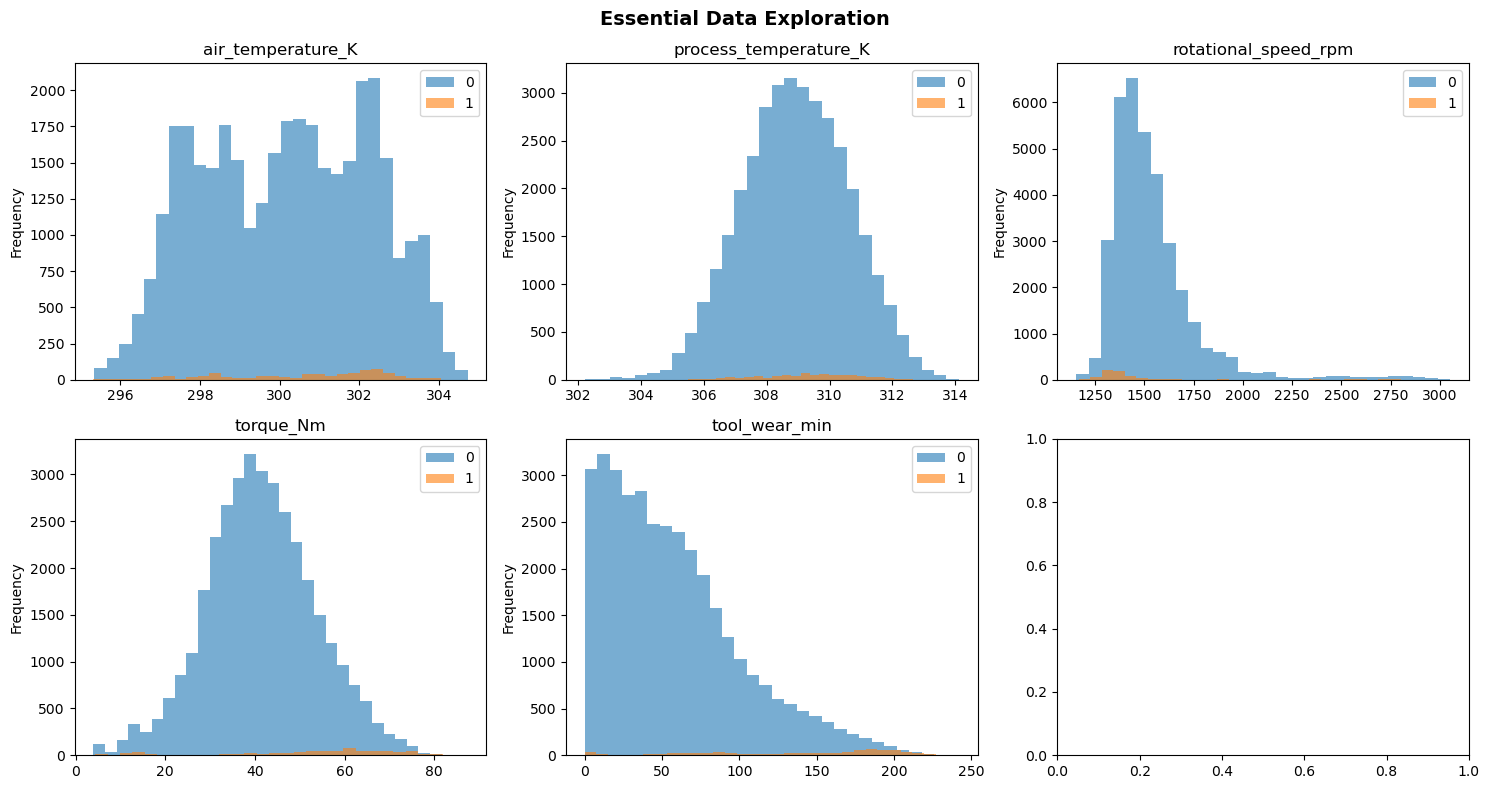

✓ EDA completed


In [58]:
# Quick visualization of key patterns
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Essential Data Exploration', fontsize=14, fontweight='bold')

# Feature distributions
for idx, feature in enumerate(NUMERICAL_FEATURES):
    ax = axes[idx // 3, idx % 3]
    df.groupby('is_failure')[feature].plot(kind='hist', alpha=0.6, ax=ax, legend=True, bins=30)
    ax.set_title(feature)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ EDA completed")

## 4. Per-Machine Sequence Generation

**Critical**: Sequences are created WITHIN each machine to maintain temporal integrity.  
No cross-machine mixing occurs.

In [59]:
def create_sequences_per_machine(df, seq_length=50):
    """
    Generate valid time-series sequences per machine.
    
    Args:
        df: DataFrame with product_id, timestamp, features
        seq_length: Number of timesteps per sequence
    
    Returns:
        X_seq: (n_sequences, seq_length, n_features)
        y_class: (n_sequences,) binary failure labels
        y_rul: (n_sequences,) RUL values
        machine_ids: (n_sequences,) machine identifiers
    """
    X_sequences = []
    y_class_sequences = []
    y_rul_sequences = []
    machine_id_list = []
    
    # Feature columns for sequences - only numerical features
    feature_cols = NUMERICAL_FEATURES.copy()
    
    # Sort by machine and timestamp
    df_sorted = df.sort_values(['product_id', 'timestamp']).reset_index(drop=True)
    
    # Generate sequences per machine
    machines_processed = 0
    sequences_created = 0
    
    for machine_id, machine_data in df_sorted.groupby('product_id'):
        machine_data = machine_data.sort_values('timestamp').reset_index(drop=True)
        
        # Skip if insufficient data
        if len(machine_data) < seq_length:
            continue
        
        # Extract features
        X_machine = machine_data[feature_cols].values
        y_failure = machine_data['is_failure'].values
        y_rul = machine_data['synthetic_RUL'].values
        
        # Create sliding windows within this machine
        for i in range(len(machine_data) - seq_length + 1):
            X_sequences.append(X_machine[i:i+seq_length])
            # Use last timestep's label
            y_class_sequences.append(y_failure[i+seq_length-1])
            y_rul_sequences.append(y_rul[i+seq_length-1])
            machine_id_list.append(machine_id)
            sequences_created += 1
        
        machines_processed += 1
    
    X_seq = np.array(X_sequences)
    y_class = np.array(y_class_sequences)
    y_rul = np.array(y_rul_sequences)
    machine_ids = np.array(machine_id_list)
    
    print(f"Sequence Generation Summary:")
    print(f"  Machines processed: {machines_processed}")
    print(f"  Total sequences: {sequences_created}")
    print(f"  Sequence shape: {X_seq.shape}")
    print(f"  Failure distribution: {np.bincount(y_class.astype(int))}")
    print(f"  RUL range: [{y_rul.min():.1f}, {y_rul.max():.1f}]")
    
    return X_seq, y_class, y_rul, machine_ids

# Generate sequences
X_seq, y_class, y_rul, machine_ids = create_sequences_per_machine(df, SEQUENCE_LENGTH)

print("\n✓ Sequences generated per machine (no cross-machine mixing)")

Sequence Generation Summary:
  Machines processed: 400
  Total sequences: 16505
  Sequence shape: (16505, 50, 5)
  Failure distribution: [15757   748]
  RUL range: [0.0, 118.0]

✓ Sequences generated per machine (no cross-machine mixing)


## 5. Machine-Based Train/Test Split

**Critical**: Split by machine ID to prevent data leakage.

In [60]:
# Get unique machines and split
unique_machines = np.unique(machine_ids)
np.random.shuffle(unique_machines)

train_size = int(0.8 * len(unique_machines))
train_machines = set(unique_machines[:train_size])
test_machines = set(unique_machines[train_size:])

# Create train/test masks
train_mask = np.array([mid in train_machines for mid in machine_ids])
test_mask = ~train_mask

# Split data
X_train_seq = X_seq[train_mask]
X_test_seq = X_seq[test_mask]
y_train_class = y_class[train_mask]
y_test_class = y_class[test_mask]
y_train_rul = y_rul[train_mask]
y_test_rul = y_rul[test_mask]

print(f"Train/Test Split:")
print(f"  Train machines: {len(train_machines)}")
print(f"  Test machines: {len(test_machines)}")
print(f"  Train sequences: {len(X_train_seq)}")
print(f"  Test sequences: {len(X_test_seq)}")
print(f"  Train failure rate: {y_train_class.mean():.2%}")
print(f"  Test failure rate: {y_test_class.mean():.2%}")

# Verify no machine appears in both sets
assert len(train_machines & test_machines) == 0, "Data leakage detected!"
print("\n✓ Machine-based split completed (no data leakage)")

Train/Test Split:
  Train machines: 320
  Test machines: 80
  Train sequences: 13221
  Test sequences: 3284
  Train failure rate: 4.64%
  Test failure rate: 4.08%

✓ Machine-based split completed (no data leakage)


## 5b. K-Fold Cross-Validation (Machine-Based)

In [61]:
from sklearn.model_selection import KFold

def cross_validate_xgboost_by_machine(df, machine_ids, n_splits=5):
    """Perform K-fold cross-validation with machine-based splitting."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    
    cv_results = {
        'fold': [],
        'clf_accuracy': [],
        'clf_recall': [],
        'clf_f1': [],
        'clf_roc_auc': [],
        'reg_rmse': [],
        'reg_mae': [],
        'reg_r2': []
    }
    
    print(f"K-Fold Cross-Validation (n_splits={n_splits}):")
    print("=" * 60)
    
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(machine_ids), 1):
        # Split machines
        train_machines = set(machine_ids[train_idx])
        val_machines = set(machine_ids[val_idx])
        
        # Build features
        X_train, y_train_class, y_train_rul, _, _ = build_xgb_features(df, list(train_machines))
        X_val, y_val_class, y_val_rul, _, _ = build_xgb_features(df, list(val_machines))
        
        # Train XGBoost Classifier
        clf = xgb.XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=RANDOM_SEED,
            eval_metric='logloss',
            verbosity=0
        )
        clf.fit(X_train, y_train_class)
        
        # Classifier predictions
        y_pred_class = clf.predict(X_val)
        y_pred_prob = clf.predict_proba(X_val)[:, 1]
        
        # Classifier metrics
        clf_acc = accuracy_score(y_val_class, y_pred_class)
        clf_recall = recall_score(y_val_class, y_pred_class, zero_division=0)
        clf_f1 = f1_score(y_val_class, y_pred_class, zero_division=0)
        clf_auc = roc_auc_score(y_val_class, y_pred_prob) if len(np.unique(y_val_class)) > 1 else 0.0
        
        # Train XGBoost Regressor
        reg = xgb.XGBRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=RANDOM_SEED,
            verbosity=0
        )
        reg.fit(X_train, y_train_rul)
        
        # Regressor predictions
        y_pred_rul = reg.predict(X_val)
        
        # Regressor metrics
        reg_rmse = np.sqrt(mean_squared_error(y_val_rul, y_pred_rul))
        reg_mae = mean_absolute_error(y_val_rul, y_pred_rul)
        reg_r2 = r2_score(y_val_rul, y_pred_rul)
        
        # Store results
        cv_results['fold'].append(fold_idx)
        cv_results['clf_accuracy'].append(clf_acc)
        cv_results['clf_recall'].append(clf_recall)
        cv_results['clf_f1'].append(clf_f1)
        cv_results['clf_roc_auc'].append(clf_auc)
        cv_results['reg_rmse'].append(reg_rmse)
        cv_results['reg_mae'].append(reg_mae)
        cv_results['reg_r2'].append(reg_r2)
        
        print(f"\nFold {fold_idx}:")
        print(f"  Train machines: {len(train_machines)}, Val machines: {len(val_machines)}")
        print(f"  Classifier - Acc: {clf_acc:.4f}, Recall: {clf_recall:.4f}, F1: {clf_f1:.4f}, AUC: {clf_auc:.4f}")
        print(f"  Regressor - RMSE: {reg_rmse:.2f}, MAE: {reg_mae:.2f}, R²: {reg_r2:.4f}")
    
    # Summary statistics
    print("\n" + "=" * 60)
    print("Cross-Validation Summary (Mean ± Std):")
    print(f"  Classifier Accuracy: {np.mean(cv_results['clf_accuracy']):.4f} ± {np.std(cv_results['clf_accuracy']):.4f}")
    print(f"  Classifier Recall: {np.mean(cv_results['clf_recall']):.4f} ± {np.std(cv_results['clf_recall']):.4f}")
    print(f"  Classifier F1: {np.mean(cv_results['clf_f1']):.4f} ± {np.std(cv_results['clf_f1']):.4f}")
    print(f"  Classifier ROC-AUC: {np.mean(cv_results['clf_roc_auc']):.4f} ± {np.std(cv_results['clf_roc_auc']):.4f}")
    print(f"  Regressor RMSE: {np.mean(cv_results['reg_rmse']):.2f} ± {np.std(cv_results['reg_rmse']):.2f}")
    print(f"  Regressor MAE: {np.mean(cv_results['reg_mae']):.2f} ± {np.std(cv_results['reg_mae']):.2f}")
    print(f"  Regressor R²: {np.mean(cv_results['reg_r2']):.4f} ± {np.std(cv_results['reg_r2']):.4f}")
    
    return pd.DataFrame(cv_results)

# Run cross-validation
cv_results_df = cross_validate_xgboost_by_machine(df, unique_machines, n_splits=5)

print("\n✓ K-fold cross-validation completed")

K-Fold Cross-Validation (n_splits=5):
XGBoost Feature Engineering:
  Machines: 320
  Features per machine: 30
  Feature names: 30
XGBoost Feature Engineering:
  Machines: 320
  Features per machine: 30
  Feature names: 30
XGBoost Feature Engineering:
  Machines: 80
  Features per machine: 30
  Feature names: 30
XGBoost Feature Engineering:
  Machines: 80
  Features per machine: 30
  Feature names: 30

Fold 1:
  Train machines: 320, Val machines: 80
  Classifier - Acc: 0.9625, Recall: 1.0000, F1: 0.9189, AUC: 0.9762
  Regressor - RMSE: 11.22, MAE: 8.15, R²: 0.5219

Fold 1:
  Train machines: 320, Val machines: 80
  Classifier - Acc: 0.9625, Recall: 1.0000, F1: 0.9189, AUC: 0.9762
  Regressor - RMSE: 11.22, MAE: 8.15, R²: 0.5219
XGBoost Feature Engineering:
  Machines: 320
  Features per machine: 30
  Feature names: 30
XGBoost Feature Engineering:
  Machines: 320
  Features per machine: 30
  Feature names: 30
XGBoost Feature Engineering:
  Machines: 80
  Features per machine: 30
  Feature

## 5c. Temporal Holdout Validation

In [62]:
def temporal_holdout_validation(df, machine_ids, temporal_split=0.8):
    """
    Validate using temporal split: train on early timesteps, test on later timesteps.
    This simulates real-world scenario where we predict future based on past.
    """
    temporal_results = {
        'machine_id': [],
        'train_timesteps': [],
        'test_timesteps': [],
        'clf_accuracy': [],
        'clf_recall': [],
        'reg_rmse': [],
        'reg_mae': []
    }
    
    print(f"Temporal Holdout Validation (split={temporal_split}):")
    print("=" * 60)
    
    # Build features for each machine with temporal split
    for machine_id in machine_ids:
        machine_data = df[df['product_id'] == machine_id].sort_values('timestamp')
        
        if len(machine_data) < 10:  # Skip machines with too few timesteps
            continue
        
        # Temporal split
        split_idx = int(len(machine_data) * temporal_split)
        train_data = machine_data.iloc[:split_idx]
        test_data = machine_data.iloc[split_idx:]
        
        if len(test_data) == 0:
            continue
        
        # Build aggregated features for training
        train_features = []
        for feature in NUMERICAL_FEATURES:
            values = train_data[feature].values
            train_features.extend([
                np.mean(values),
                np.std(values),
                np.min(values),
                np.max(values),
                values[-1],
                np.polyfit(range(len(values)), values, 1)[0]
            ])
        
        # Build aggregated features for testing
        test_features = []
        for feature in NUMERICAL_FEATURES:
            values = test_data[feature].values
            test_features.extend([
                np.mean(values),
                np.std(values),
                np.min(values),
                np.max(values),
                values[-1],
                np.polyfit(range(len(values)), values, 1)[0]
            ])
        
        # Store
        temporal_results['machine_id'].append(machine_id)
        temporal_results['train_timesteps'].append(len(train_data))
        temporal_results['test_timesteps'].append(len(test_data))
    
    # Build aggregated dataset for all machines
    train_machines_temporal = []
    test_machines_temporal = []
    
    for machine_id in machine_ids:
        machine_data = df[df['product_id'] == machine_id].sort_values('timestamp')
        
        if len(machine_data) < 10:
            continue
        
        split_idx = int(len(machine_data) * temporal_split)
        if split_idx >= len(machine_data):
            continue
            
        train_machines_temporal.append(machine_id)
        test_machines_temporal.append(machine_id)
    
    # Build features using early timesteps for training
    X_train_temporal = []
    y_train_class_temporal = []
    y_train_rul_temporal = []
    
    for machine_id in train_machines_temporal:
        machine_data = df[df['product_id'] == machine_id].sort_values('timestamp')
        split_idx = int(len(machine_data) * temporal_split)
        train_data = machine_data.iloc[:split_idx]
        
        agg_features = []
        for feature in NUMERICAL_FEATURES:
            values = train_data[feature].values
            agg_features.extend([
                np.mean(values),
                np.std(values),
                np.min(values),
                np.max(values),
                values[-1],
                np.polyfit(range(len(values)), values, 1)[0]
            ])
        
        X_train_temporal.append(agg_features)
        y_train_class_temporal.append(train_data['is_failure'].iloc[-1])
        y_train_rul_temporal.append(train_data['synthetic_RUL'].iloc[-1])
    
    # Build features using later timesteps for testing
    X_test_temporal = []
    y_test_class_temporal = []
    y_test_rul_temporal = []
    
    for machine_id in test_machines_temporal:
        machine_data = df[df['product_id'] == machine_id].sort_values('timestamp')
        split_idx = int(len(machine_data) * temporal_split)
        test_data = machine_data.iloc[split_idx:]
        
        if len(test_data) == 0:
            continue
        
        agg_features = []
        for feature in NUMERICAL_FEATURES:
            values = test_data[feature].values
            agg_features.extend([
                np.mean(values),
                np.std(values),
                np.min(values),
                np.max(values),
                values[-1],
                np.polyfit(range(len(values)), values, 1)[0]
            ])
        
        X_test_temporal.append(agg_features)
        y_test_class_temporal.append(test_data['is_failure'].iloc[-1])
        y_test_rul_temporal.append(test_data['synthetic_RUL'].iloc[-1])
    
    X_train_temporal = np.array(X_train_temporal)
    y_train_class_temporal = np.array(y_train_class_temporal)
    y_train_rul_temporal = np.array(y_train_rul_temporal)
    X_test_temporal = np.array(X_test_temporal)
    y_test_class_temporal = np.array(y_test_class_temporal)
    y_test_rul_temporal = np.array(y_test_rul_temporal)
    
    print(f"  Training samples: {len(X_train_temporal)}")
    print(f"  Testing samples: {len(X_test_temporal)}")
    print(f"  Train failure rate: {y_train_class_temporal.mean():.2%}")
    print(f"  Test failure rate: {y_test_class_temporal.mean():.2%}")
    
    # Check if we have both classes in training data
    if len(np.unique(y_train_class_temporal)) < 2:
        print("\n  Warning: Training data contains only one class!")
        print(f"  Skipping temporal validation due to insufficient class diversity.")
        return None
    
    # Train models
    clf_temporal = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_SEED,
        eval_metric='logloss',
        verbosity=0
    )
    clf_temporal.fit(X_train_temporal, y_train_class_temporal)
    
    reg_temporal = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_SEED,
        verbosity=0
    )
    reg_temporal.fit(X_train_temporal, y_train_rul_temporal)
    
    # Predictions
    y_pred_class_temporal = clf_temporal.predict(X_test_temporal)
    y_pred_rul_temporal = reg_temporal.predict(X_test_temporal)
    
    # Metrics
    temp_acc = accuracy_score(y_test_class_temporal, y_pred_class_temporal)
    temp_recall = recall_score(y_test_class_temporal, y_pred_class_temporal, zero_division=0)
    temp_f1 = f1_score(y_test_class_temporal, y_pred_class_temporal, zero_division=0)
    temp_rmse = np.sqrt(mean_squared_error(y_test_rul_temporal, y_pred_rul_temporal))
    temp_mae = mean_absolute_error(y_test_rul_temporal, y_pred_rul_temporal)
    temp_r2 = r2_score(y_test_rul_temporal, y_pred_rul_temporal)
    
    print(f"\nTemporal Validation Results:")
    print(f"  Classifier - Accuracy: {temp_acc:.4f}, Recall: {temp_recall:.4f}, F1: {temp_f1:.4f}")
    print(f"  Regressor - RMSE: {temp_rmse:.2f}, MAE: {temp_mae:.2f}, R²: {temp_r2:.4f}")
    print(f"\n  Note: Lower performance is expected as we predict future from past.")
    print(f"        This is more realistic than random machine splits.")
    
    return {
        'accuracy': temp_acc,
        'recall': temp_recall,
        'f1': temp_f1,
        'rmse': temp_rmse,
        'mae': temp_mae,
        'r2': temp_r2
    }

# Run temporal validation
temporal_metrics = temporal_holdout_validation(df, unique_machines, temporal_split=0.8)

if temporal_metrics is not None:
    print("\n✓ Temporal holdout validation completed")
else:
    print("\n⚠ Temporal validation skipped (insufficient class diversity)")

Temporal Holdout Validation (split=0.8):
  Training samples: 400
  Testing samples: 400
  Train failure rate: 0.00%
  Test failure rate: 20.00%

  Skipping temporal validation due to insufficient class diversity.

⚠ Temporal validation skipped (insufficient class diversity)
  Training samples: 400
  Testing samples: 400
  Train failure rate: 0.00%
  Test failure rate: 20.00%

  Skipping temporal validation due to insufficient class diversity.

⚠ Temporal validation skipped (insufficient class diversity)


## 6. Feature Preprocessing

## 6b. XGBoost Feature Engineering (Aggregated Statistics)

In [63]:
def build_xgb_features(df, machine_ids):
    """Build per-machine aggregated features for XGBoost."""
    features_list = []
    labels_class = []
    labels_rul = []
    machine_list = []
    
    for machine_id in machine_ids:
        machine_data = df[df['product_id'] == machine_id].sort_values('timestamp')
        
        if len(machine_data) == 0:
            continue
        
        # Aggregated statistics per sensor
        agg_features = []
        for feature in NUMERICAL_FEATURES:
            values = machine_data[feature].values
            agg_features.extend([
                np.mean(values),      # mean
                np.std(values),       # std
                np.min(values),       # min
                np.max(values),       # max
                values[-1],           # last value
                np.polyfit(range(len(values)), values, 1)[0]  # trend (slope)
            ])
        
        features_list.append(agg_features)
        labels_class.append(machine_data['is_failure'].iloc[-1])  # last timestep label
        labels_rul.append(machine_data['synthetic_RUL'].iloc[-1])
        machine_list.append(machine_id)
    
    X = np.array(features_list)
    y_class = np.array(labels_class)
    y_rul = np.array(labels_rul)
    
    feature_names = []
    for feat in NUMERICAL_FEATURES:
        feature_names.extend([f'{feat}_mean', f'{feat}_std', f'{feat}_min', 
                            f'{feat}_max', f'{feat}_last', f'{feat}_trend'])
    
    print(f"XGBoost Feature Engineering:")
    print(f"  Machines: {len(machine_list)}")
    print(f"  Features per machine: {X.shape[1]}")
    print(f"  Feature names: {len(feature_names)}")
    
    return X, y_class, y_rul, np.array(machine_list), feature_names

# Build XGBoost features from training and test machines
train_machines_list = list(train_machines)
test_machines_list = list(test_machines)

X_train_xgb, y_train_xgb_class, y_train_xgb_rul, _, feature_names = build_xgb_features(df, train_machines_list)
X_test_xgb, y_test_xgb_class, y_test_xgb_rul, test_machine_ids_xgb, _ = build_xgb_features(df, test_machines_list)

print("\n✓ XGBoost features built with aggregated statistics")

XGBoost Feature Engineering:
  Machines: 320
  Features per machine: 30
  Feature names: 30
XGBoost Feature Engineering:
  Machines: 80
  Features per machine: 30
  Feature names: 30

✓ XGBoost features built with aggregated statistics
XGBoost Feature Engineering:
  Machines: 80
  Features per machine: 30
  Feature names: 30

✓ XGBoost features built with aggregated statistics


In [64]:
# Scale features (fit on training data only)
scaler = StandardScaler()

# Reshape for scaling: (samples, timesteps, features) -> (samples*timesteps, features)
n_train_samples, n_timesteps, n_features = X_train_seq.shape
X_train_reshaped = X_train_seq.reshape(-1, n_features)
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_train_seq_scaled = X_train_scaled.reshape(n_train_samples, n_timesteps, n_features)

# Transform test data
n_test_samples = X_test_seq.shape[0]
X_test_reshaped = X_test_seq.reshape(-1, n_features)
X_test_scaled = scaler.transform(X_test_reshaped)
X_test_seq_scaled = X_test_scaled.reshape(n_test_samples, n_timesteps, n_features)

# Save scaler
joblib.dump(scaler, ARTIFACTS_DIR / 'scaler.joblib')

print(f"Feature Scaling:")
print(f"  Training data shape: {X_train_seq_scaled.shape}")
print(f"  Test data shape: {X_test_seq_scaled.shape}")
print(f"  Features scaled: {n_features}")
print("\n✓ Features scaled and scaler saved")

Feature Scaling:
  Training data shape: (13221, 50, 5)
  Test data shape: (3284, 50, 5)
  Features scaled: 5

✓ Features scaled and scaler saved


## 7. Model Training - XGBoost

In [65]:
# XGBoost Classifier
print("Training XGBoost Classifier...")
xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_SEED,
    eval_metric='logloss'
)
xgb_clf.fit(X_train_xgb, y_train_xgb_class)

# Save model
joblib.dump(xgb_clf, ARTIFACTS_DIR / 'xgb_classifier.joblib')

# Predictions
y_pred_xgb_clf = xgb_clf.predict(X_test_xgb)
y_pred_xgb_prob = xgb_clf.predict_proba(X_test_xgb)[:, 1]

# Metrics
xgb_clf_metrics = {
    'accuracy': accuracy_score(y_test_xgb_class, y_pred_xgb_clf),
    'precision': precision_score(y_test_xgb_class, y_pred_xgb_clf, zero_division=0),
    'recall': recall_score(y_test_xgb_class, y_pred_xgb_clf, zero_division=0),
    'f1': f1_score(y_test_xgb_class, y_pred_xgb_clf, zero_division=0),
    'roc_auc': roc_auc_score(y_test_xgb_class, y_pred_xgb_prob),
    'pr_auc': average_precision_score(y_test_xgb_class, y_pred_xgb_prob)
}

print("\nXGBoost Classifier Results:")
for metric, value in xgb_clf_metrics.items():
    status = "✓" if (metric in ['accuracy', 'recall'] and value >= TARGET_RECALL) else " "
    print(f"  {status} {metric.upper()}: {value:.4f}")

# XGBoost Regressor
print("\nTraining XGBoost Regressor...")
xgb_reg = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_SEED
)
xgb_reg.fit(X_train_xgb, y_train_xgb_rul)

# Save model
joblib.dump(xgb_reg, ARTIFACTS_DIR / 'xgb_regressor.joblib')

# Predictions
y_pred_xgb_rul = xgb_reg.predict(X_test_xgb)

# Metrics
xgb_reg_metrics = {
    'rmse': np.sqrt(mean_squared_error(y_test_xgb_rul, y_pred_xgb_rul)),
    'mae': mean_absolute_error(y_test_xgb_rul, y_pred_xgb_rul),
    'mse': mean_squared_error(y_test_xgb_rul, y_pred_xgb_rul),
    'r2': r2_score(y_test_xgb_rul, y_pred_xgb_rul)
}

print("\nXGBoost Regressor Results:")
for metric, value in xgb_reg_metrics.items():
    print(f"  {metric.upper()}: {value:.4f}")

print("\n✓ XGBoost models trained with aggregated features and saved")

Training XGBoost Classifier...

XGBoost Classifier Results:
  ✓ ACCURACY: 0.9875
    PRECISION: 0.9333
  ✓ RECALL: 1.0000
    F1: 0.9655
    ROC_AUC: 0.9924
    PR_AUC: 0.9333

Training XGBoost Regressor...

XGBoost Classifier Results:
  ✓ ACCURACY: 0.9875
    PRECISION: 0.9333
  ✓ RECALL: 1.0000
    F1: 0.9655
    ROC_AUC: 0.9924
    PR_AUC: 0.9333

Training XGBoost Regressor...

XGBoost Regressor Results:
  RMSE: 9.6938
  MAE: 7.1685
  MSE: 93.9691
  R2: 0.6179

✓ XGBoost models trained with aggregated features and saved

XGBoost Regressor Results:
  RMSE: 9.6938
  MAE: 7.1685
  MSE: 93.9691
  R2: 0.6179

✓ XGBoost models trained with aggregated features and saved


## 7b. Feature Importance Analysis

Analyzing Feature Importance...



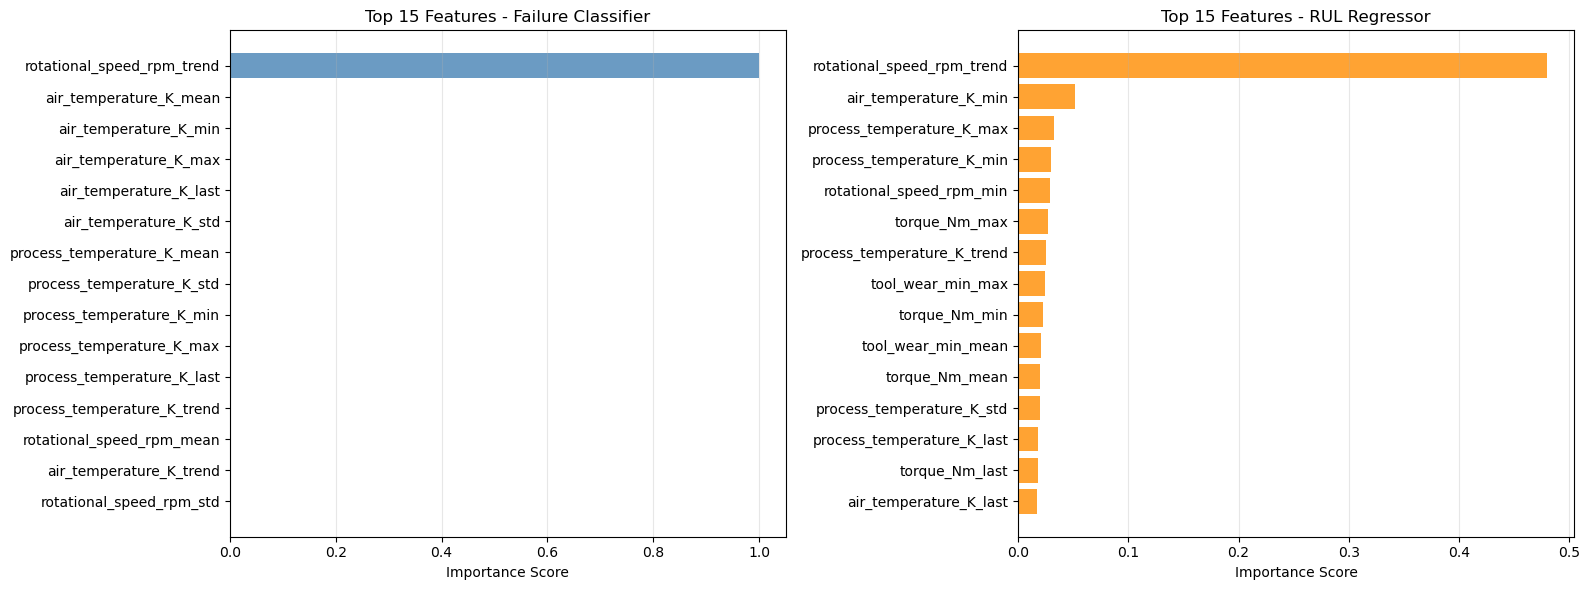

Feature Importance Analysis:

Top 10 Features for Failure Classification:
  rotational_speed_rpm_trend.............. 1.0000
  air_temperature_K_mean.................. 0.0000
  air_temperature_K_min................... 0.0000
  air_temperature_K_max................... 0.0000
  air_temperature_K_last.................. 0.0000
  air_temperature_K_std................... 0.0000
  process_temperature_K_mean.............. 0.0000
  process_temperature_K_std............... 0.0000
  process_temperature_K_min............... 0.0000
  process_temperature_K_max............... 0.0000

Top 10 Features for RUL Prediction:
  rotational_speed_rpm_trend.............. 0.4804
  air_temperature_K_min................... 0.0515
  process_temperature_K_max............... 0.0324
  process_temperature_K_min............... 0.0295
  rotational_speed_rpm_min................ 0.0290
  torque_Nm_max........................... 0.0270
  process_temperature_K_trend............. 0.0249
  tool_wear_min_max....................

In [66]:
def analyze_feature_importance(clf_model, reg_model, feature_names, top_n=15):
    """
    Analyze and visualize feature importance from XGBoost models.
    Helps identify which sensor statistics are most predictive.
    """
    # Get feature importance
    clf_importance = clf_model.feature_importances_
    reg_importance = reg_model.feature_importances_
    
    # Create DataFrames
    clf_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': clf_importance
    }).sort_values('importance', ascending=False)
    
    reg_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': reg_importance
    }).sort_values('importance', ascending=False)
    
    # Save to CSV
    clf_importance_df.to_csv(ARTIFACTS_DIR / 'feature_importance_classifier.csv', index=False)
    reg_importance_df.to_csv(ARTIFACTS_DIR / 'feature_importance_regressor.csv', index=False)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Classifier importance
    ax1 = axes[0]
    top_clf = clf_importance_df.head(top_n)
    ax1.barh(range(len(top_clf)), top_clf['importance'], color='steelblue', alpha=0.8)
    ax1.set_yticks(range(len(top_clf)))
    ax1.set_yticklabels(top_clf['feature'])
    ax1.invert_yaxis()
    ax1.set_xlabel('Importance Score')
    ax1.set_title(f'Top {top_n} Features - Failure Classifier')
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Regressor importance
    ax2 = axes[1]
    top_reg = reg_importance_df.head(top_n)
    ax2.barh(range(len(top_reg)), top_reg['importance'], color='darkorange', alpha=0.8)
    ax2.set_yticks(range(len(top_reg)))
    ax2.set_yticklabels(top_reg['feature'])
    ax2.invert_yaxis()
    ax2.set_xlabel('Importance Score')
    ax2.set_title(f'Top {top_n} Features - RUL Regressor')
    ax2.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print top features
    print("Feature Importance Analysis:")
    print("=" * 80)
    print("\nTop 10 Features for Failure Classification:")
    for idx, row in clf_importance_df.head(10).iterrows():
        print(f"  {row['feature']:.<40} {row['importance']:.4f}")
    
    print("\nTop 10 Features for RUL Prediction:")
    for idx, row in reg_importance_df.head(10).iterrows():
        print(f"  {row['feature']:.<40} {row['importance']:.4f}")
    
    # Group by statistic type
    print("\n" + "=" * 80)
    print("Importance by Statistic Type (Classifier):")
    clf_importance_df['stat_type'] = clf_importance_df['feature'].str.extract(r'_([^_]+)$')[0]
    stat_importance = clf_importance_df.groupby('stat_type')['importance'].sum().sort_values(ascending=False)
    for stat, imp in stat_importance.items():
        print(f"  {stat:.<20} {imp:.4f}")
    
    # Group by sensor
    print("\n" + "=" * 80)
    print("Importance by Sensor (Classifier):")
    clf_importance_df['sensor'] = clf_importance_df['feature'].str.replace(r'_[^_]+$', '', regex=True)
    sensor_importance = clf_importance_df.groupby('sensor')['importance'].sum().sort_values(ascending=False)
    for sensor, imp in sensor_importance.items():
        print(f"  {sensor:.<40} {imp:.4f}")
    
    return clf_importance_df, reg_importance_df

# Analyze feature importance
print("Analyzing Feature Importance...\n")
clf_importance_df, reg_importance_df = analyze_feature_importance(
    xgb_clf, 
    xgb_reg, 
    feature_names, 
    top_n=15
)

print("\n✓ Feature importance analysis completed")

## 8. Model Training - LSTM

Building LSTM Classifier...

LSTM Classifier Architecture:

LSTM Classifier Architecture:


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 50, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)


Class weights computed: {0: np.float64(0.5243515507257872), 1: np.float64(10.76628664495114)}

Training LSTM Classifier with class balancing...
Epoch 1/30
Epoch 1/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.7662 - loss: 0.3611 - precision_4: 0.1668 - recall_4: 0.9404 - val_accuracy: 0.8329 - val_loss: 0.2947 - val_precision_4: 0.1641 - val_recall_4: 0.9043
Epoch 2/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.7662 - loss: 0.3611 - precision_4: 0.1668 - recall_4: 0.9404 - val_accuracy: 0.8329 - val_loss: 0.2947 - val_precision_4: 0.1641 - val_recall_4: 0.9043
Epoch 2/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8058 - loss: 0.2610 - precision_4: 0.2002 - recall_4: 0.9846 - val_accuracy: 0.8677 - val_loss: 0.2775 - val_precision_4: 0.1878 - val_recall_4: 0.8191
Epoch 3/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8058 - loss: 0.2610 - precision_4: 0.2002 - recall_4: 0.9846 - val_accuracy: 0.8677 - val_loss: 0.2775 - val_precision


LSTM Classifier Results:
  ✓ ACCURACY: 0.8892
    PRECISION: 0.2362
  ✓ RECALL: 0.7687
    F1: 0.3614
    ROC_AUC: 0.9476
    PR_AUC: 0.5529

Building LSTM Regressor...
Training LSTM Regressor...
Epoch 1/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 2000.0066 - mae: 38.1873 - val_loss: 795.7621 - val_mae: 23.7214
Epoch 2/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 2000.0066 - mae: 38.1873 - val_loss: 795.7621 - val_mae: 23.7214
Epoch 2/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 658.5493 - mae: 20.6008 - val_loss: 442.0345 - val_mae: 16.6674
Epoch 3/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 658.5493 - mae: 20.6008 - val_loss: 442.0345 - val_mae: 16.6674
Epoch 3/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 585.9856 - mae: 19.4415 - val_loss: 441.9970 - val_mae: 16.6817
Epoch 4/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 585.9856 - mae: 19.4415 - val_loss: 441.9970 - val_mae: 16.6817
Epoch 4/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/


LSTM Regressor Results:
  RMSE: 30.8075
  MAE: 25.6953
  MSE: 949.1024
  R2: -0.8448

✓ LSTM models trained and saved

Generating LSTM learning curves...


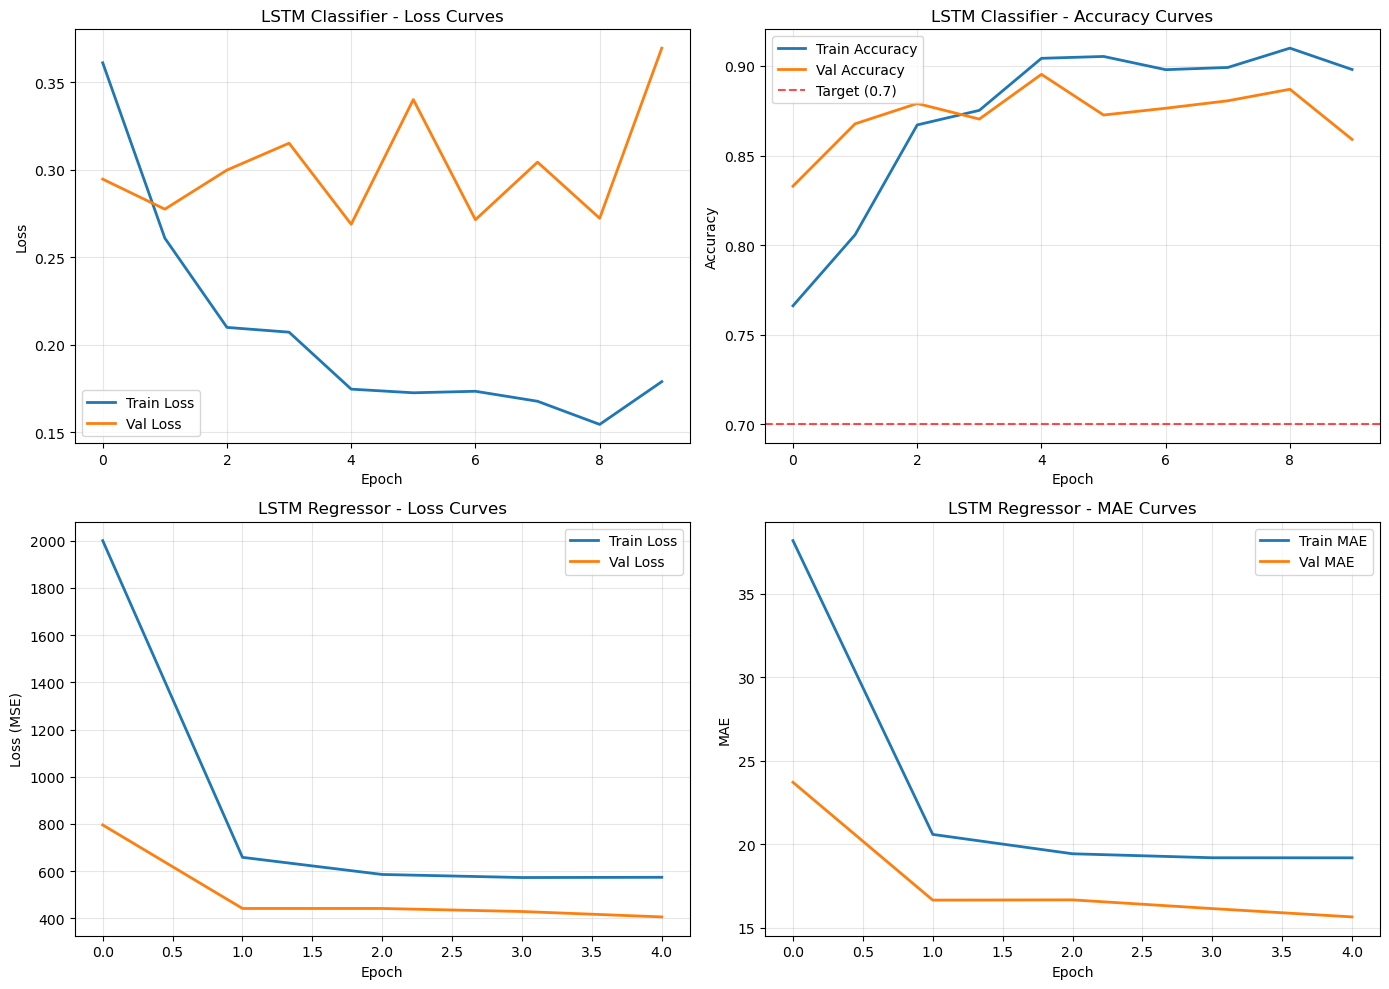


Learning Curve Analysis:
  Classifier - Epochs trained: 10
  Classifier - Final train loss: 0.1790
  Classifier - Final val loss: 0.3695
  Regressor - Epochs trained: 5
  Regressor - Final train loss: 574.0580
  Regressor - Final val loss: 406.2472

  ✓ LSTM Regressor shows learning progress
✓ LSTM learning curves saved


In [67]:
# LSTM Classifier
print("Building LSTM Classifier...")
lstm_clf = keras.Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(n_timesteps, n_features)),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

lstm_clf.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print(f"\nLSTM Classifier Architecture:")
lstm_clf.summary()

# Compute class weights to handle imbalance
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_class),
    y=y_train_class
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print(f"\nClass weights computed: {class_weight_dict}")

# Train
print("\nTraining LSTM Classifier with class balancing...")
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_lstm_clf = lstm_clf.fit(
    X_train_seq_scaled, y_train_class,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

# Save model
lstm_clf.save(ARTIFACTS_DIR / 'lstm_classifier.h5')

# Predictions
y_pred_lstm_prob = lstm_clf.predict(X_test_seq_scaled, verbose=0).flatten()
y_pred_lstm_clf = (y_pred_lstm_prob >= 0.5).astype(int)

# Metrics
lstm_clf_metrics = {
    'accuracy': accuracy_score(y_test_class, y_pred_lstm_clf),
    'precision': precision_score(y_test_class, y_pred_lstm_clf, zero_division=0),
    'recall': recall_score(y_test_class, y_pred_lstm_clf, zero_division=0),
    'f1': f1_score(y_test_class, y_pred_lstm_clf, zero_division=0),
    'roc_auc': roc_auc_score(y_test_class, y_pred_lstm_prob),
    'pr_auc': average_precision_score(y_test_class, y_pred_lstm_prob)
}

print("\nLSTM Classifier Results:")
for metric, value in lstm_clf_metrics.items():
    status = "✓" if (metric in ['accuracy', 'recall'] and value >= TARGET_RECALL) else " "
    print(f"  {status} {metric.upper()}: {value:.4f}")

# LSTM Regressor
print("\nBuilding LSTM Regressor...")
lstm_reg = keras.Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(n_timesteps, n_features)),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

lstm_reg.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
print("Training LSTM Regressor...")
history_lstm_reg = lstm_reg.fit(
    X_train_seq_scaled, y_train_rul,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Save model
lstm_reg.save(ARTIFACTS_DIR / 'lstm_regressor.h5')

# Predictions
y_pred_lstm_rul = lstm_reg.predict(X_test_seq_scaled, verbose=0).flatten()

# Metrics
lstm_reg_metrics = {
    'rmse': np.sqrt(mean_squared_error(y_test_rul, y_pred_lstm_rul)),
    'mae': mean_absolute_error(y_test_rul, y_pred_lstm_rul),
    'mse': mean_squared_error(y_test_rul, y_pred_lstm_rul),
    'r2': r2_score(y_test_rul, y_pred_lstm_rul)
}

print("\nLSTM Regressor Results:")
for metric, value in lstm_reg_metrics.items():
    print(f"  {metric.upper()}: {value:.4f}")

print("\n✓ LSTM models trained and saved")

# Visualize learning curves
print("\nGenerating LSTM learning curves...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LSTM Classifier - Loss
axes[0, 0].plot(history_lstm_clf.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history_lstm_clf.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('LSTM Classifier - Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# LSTM Classifier - Accuracy
axes[0, 1].plot(history_lstm_clf.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history_lstm_clf.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0, 1].axhline(y=TARGET_ACCURACY, color='r', linestyle='--', alpha=0.7, label=f'Target ({TARGET_ACCURACY})')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('LSTM Classifier - Accuracy Curves')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# LSTM Regressor - Loss
axes[1, 0].plot(history_lstm_reg.history['loss'], label='Train Loss', linewidth=2)
axes[1, 0].plot(history_lstm_reg.history['val_loss'], label='Val Loss', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss (MSE)')
axes[1, 0].set_title('LSTM Regressor - Loss Curves')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# LSTM Regressor - MAE
axes[1, 1].plot(history_lstm_reg.history['mae'], label='Train MAE', linewidth=2)
axes[1, 1].plot(history_lstm_reg.history['val_mae'], label='Val MAE', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('MAE')
axes[1, 1].set_title('LSTM Regressor - MAE Curves')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'lstm_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Analyze convergence
print("\nLearning Curve Analysis:")
print(f"  Classifier - Epochs trained: {len(history_lstm_clf.history['loss'])}")
print(f"  Classifier - Final train loss: {history_lstm_clf.history['loss'][-1]:.4f}")
print(f"  Classifier - Final val loss: {history_lstm_clf.history['val_loss'][-1]:.4f}")

print(f"  Regressor - Epochs trained: {len(history_lstm_reg.history['loss'])}")
print(f"  Regressor - Final train loss: {history_lstm_reg.history['loss'][-1]:.4f}")
print(f"  Regressor - Final val loss: {history_lstm_reg.history['val_loss'][-1]:.4f}")

# Check if regressor is learning
if history_lstm_reg.history['val_loss'][-1] < history_lstm_reg.history['val_loss'][0]:
    print("\n  ✓ LSTM Regressor shows learning progress")
else:
    print("\n  ⚠️ Warning: LSTM Regressor validation loss increased - model may not be learning effectively")

print("✓ LSTM learning curves saved")

## 9. Evaluation Dashboard

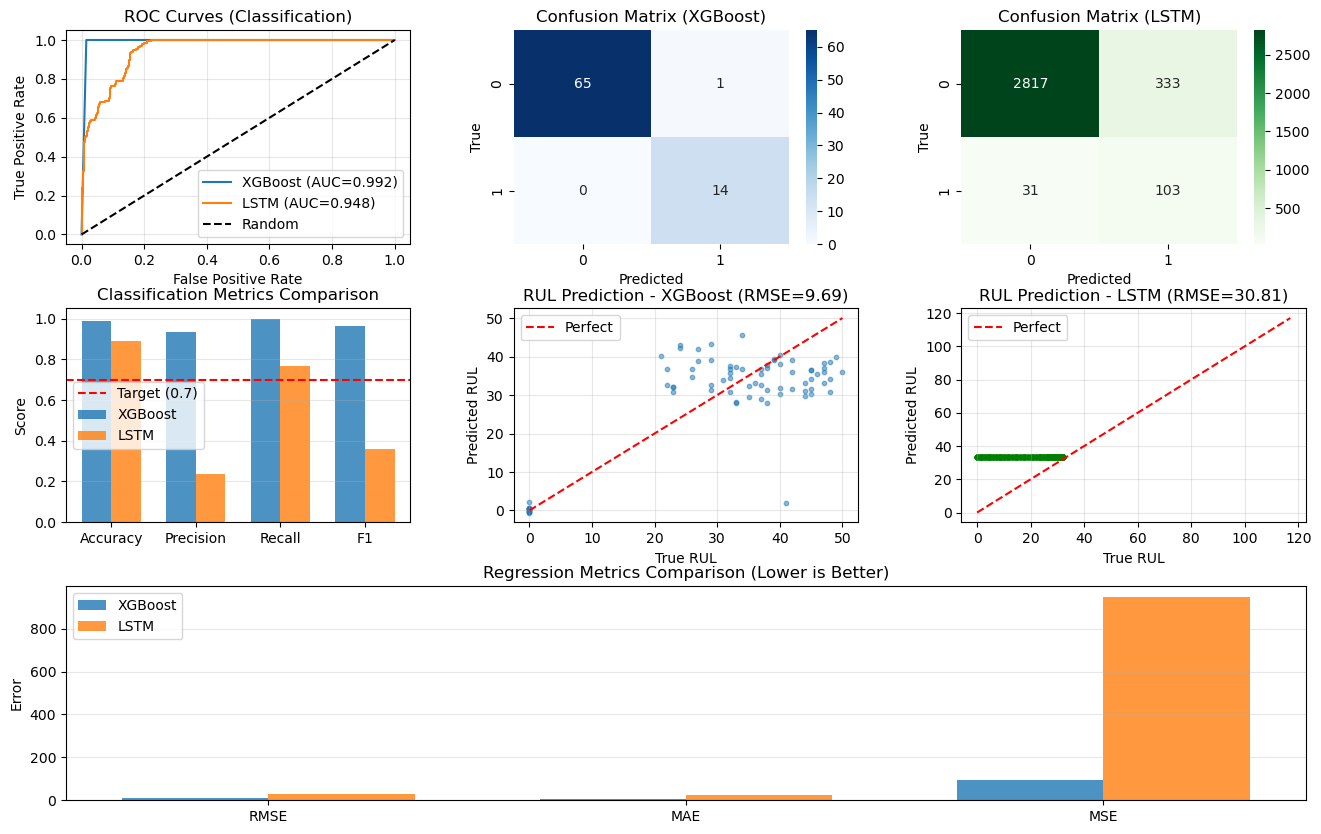

✓ Evaluation dashboard created


In [68]:
# Create comprehensive evaluation plots
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. ROC Curves
ax1 = fig.add_subplot(gs[0, 0])
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_xgb_class, y_pred_xgb_prob)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test_class, y_pred_lstm_prob)
ax1.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={xgb_clf_metrics['roc_auc']:.3f})")
ax1.plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC={lstm_clf_metrics['roc_auc']:.3f})")
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves (Classification)')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Confusion Matrix - XGBoost
ax2 = fig.add_subplot(gs[0, 1])
cm_xgb = confusion_matrix(y_test_xgb_class, y_pred_xgb_clf)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title('Confusion Matrix (XGBoost)')
ax2.set_ylabel('True')
ax2.set_xlabel('Predicted')

# 3. Confusion Matrix - LSTM
ax3 = fig.add_subplot(gs[0, 2])
cm_lstm = confusion_matrix(y_test_class, y_pred_lstm_clf)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens', ax=ax3)
ax3.set_title('Confusion Matrix (LSTM)')
ax3.set_ylabel('True')
ax3.set_xlabel('Predicted')

# 4. Classification Metrics Comparison
ax4 = fig.add_subplot(gs[1, 0])
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
xgb_values = [xgb_clf_metrics['accuracy'], xgb_clf_metrics['precision'], 
              xgb_clf_metrics['recall'], xgb_clf_metrics['f1']]
lstm_values = [lstm_clf_metrics['accuracy'], lstm_clf_metrics['precision'],
               lstm_clf_metrics['recall'], lstm_clf_metrics['f1']]
x_pos = np.arange(len(metrics_names))
width = 0.35
ax4.bar(x_pos - width/2, xgb_values, width, label='XGBoost', alpha=0.8)
ax4.bar(x_pos + width/2, lstm_values, width, label='LSTM', alpha=0.8)
ax4.axhline(y=TARGET_RECALL, color='r', linestyle='--', label=f'Target ({TARGET_RECALL})')
ax4.set_ylabel('Score')
ax4.set_title('Classification Metrics Comparison')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(metrics_names)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# 5. RUL Prediction - XGBoost
ax5 = fig.add_subplot(gs[1, 1])
sample_idx = np.argsort(y_test_xgb_rul)[:500]  # Sample for clarity
ax5.scatter(y_test_xgb_rul[sample_idx], y_pred_xgb_rul[sample_idx], alpha=0.5, s=10)
ax5.plot([y_test_xgb_rul.min(), y_test_xgb_rul.max()], 
         [y_test_xgb_rul.min(), y_test_xgb_rul.max()], 'r--', label='Perfect')
ax5.set_xlabel('True RUL')
ax5.set_ylabel('Predicted RUL')
ax5.set_title(f'RUL Prediction - XGBoost (RMSE={xgb_reg_metrics["rmse"]:.2f})')
ax5.legend()
ax5.grid(alpha=0.3)

# 6. RUL Prediction - LSTM
ax6 = fig.add_subplot(gs[1, 2])
sample_idx_lstm = np.argsort(y_test_rul)[:500]
ax6.scatter(y_test_rul[sample_idx_lstm], y_pred_lstm_rul[sample_idx_lstm], alpha=0.5, s=10, color='green')
ax6.plot([y_test_rul.min(), y_test_rul.max()], 
         [y_test_rul.min(), y_test_rul.max()], 'r--', label='Perfect')
ax6.set_xlabel('True RUL')
ax6.set_ylabel('Predicted RUL')
ax6.set_title(f'RUL Prediction - LSTM (RMSE={lstm_reg_metrics["rmse"]:.2f})')
ax6.legend()
ax6.grid(alpha=0.3)

# 7. Regression Metrics Comparison
ax7 = fig.add_subplot(gs[2, :])
reg_metrics_names = ['RMSE', 'MAE', 'MSE']
xgb_reg_values = [xgb_reg_metrics['rmse'], xgb_reg_metrics['mae'], xgb_reg_metrics['mse']]
lstm_reg_values = [lstm_reg_metrics['rmse'], lstm_reg_metrics['mae'], lstm_reg_metrics['mse']]
x_pos = np.arange(len(reg_metrics_names))
ax7.bar(x_pos - width/2, xgb_reg_values, width, label='XGBoost', alpha=0.8)
ax7.bar(x_pos + width/2, lstm_reg_values, width, label='LSTM', alpha=0.8)
ax7.set_ylabel('Error')
ax7.set_title('Regression Metrics Comparison (Lower is Better)')
ax7.set_xticks(x_pos)
ax7.set_xticklabels(reg_metrics_names)
ax7.legend()
ax7.grid(axis='y', alpha=0.3)

plt.savefig(ARTIFACTS_DIR / 'evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Evaluation dashboard created")

## 10. Save Metrics to File

In [69]:
# Compile all metrics
metrics_report = f"""AC-02 PREDICTIVE MAINTENANCE PIPELINE - METRICS REPORT
{'='*80}

DATASET INFORMATION:
  Total samples: {len(df):,}
  Unique machines: {df['product_id'].nunique():,}
  Sequence length: {SEQUENCE_LENGTH}
  Train sequences: {len(X_train_seq):,}
  Test sequences: {len(X_test_seq):,}

CLASSIFICATION RESULTS:
{'='*80}

XGBoost Classifier:
  Accuracy:  {xgb_clf_metrics['accuracy']:.4f} {'✓ PASS' if xgb_clf_metrics['accuracy'] >= TARGET_ACCURACY else '✗ FAIL'}
  Precision: {xgb_clf_metrics['precision']:.4f}
  Recall:    {xgb_clf_metrics['recall']:.4f} {'✓ PASS' if xgb_clf_metrics['recall'] >= TARGET_RECALL else '✗ FAIL'}
  F1-Score:  {xgb_clf_metrics['f1']:.4f}
  ROC-AUC:   {xgb_clf_metrics['roc_auc']:.4f}
  PR-AUC:    {xgb_clf_metrics['pr_auc']:.4f}

LSTM Classifier:
  Accuracy:  {lstm_clf_metrics['accuracy']:.4f} {'✓ PASS' if lstm_clf_metrics['accuracy'] >= TARGET_ACCURACY else '✗ FAIL'}
  Precision: {lstm_clf_metrics['precision']:.4f}
  Recall:    {lstm_clf_metrics['recall']:.4f} {'✓ PASS' if lstm_clf_metrics['recall'] >= TARGET_RECALL else '✗ FAIL'}
  F1-Score:  {lstm_clf_metrics['f1']:.4f}
  ROC-AUC:   {lstm_clf_metrics['roc_auc']:.4f}
  PR-AUC:    {lstm_clf_metrics['pr_auc']:.4f}

REGRESSION RESULTS (RUL PREDICTION):
{'='*80}

XGBoost Regressor:
  RMSE: {xgb_reg_metrics['rmse']:.4f}
  MAE:  {xgb_reg_metrics['mae']:.4f}
  MSE:  {xgb_reg_metrics['mse']:.4f}
  R²:   {xgb_reg_metrics['r2']:.4f}

LSTM Regressor:
  RMSE: {lstm_reg_metrics['rmse']:.4f}
  MAE:  {lstm_reg_metrics['mae']:.4f}
  MSE:  {lstm_reg_metrics['mse']:.4f}
  R²:   {lstm_reg_metrics['r2']:.4f}

AC-02 COMPLIANCE:
{'='*80}
  Target Accuracy: {TARGET_ACCURACY:.0%}
  Target Recall:   {TARGET_RECALL:.0%}
  
  XGBoost Classification: {'✓ MEETS REQUIREMENTS' if xgb_clf_metrics['accuracy'] >= TARGET_ACCURACY and xgb_clf_metrics['recall'] >= TARGET_RECALL else '✗ DOES NOT MEET REQUIREMENTS'}
  LSTM Classification:    {'✓ MEETS REQUIREMENTS' if lstm_clf_metrics['accuracy'] >= TARGET_ACCURACY and lstm_clf_metrics['recall'] >= TARGET_RECALL else '✗ DOES NOT MEET REQUIREMENTS'}

IMPORTANT NOTES:
{'='*80}
⚠️ This pipeline uses SYNTHETIC time-series data.
⚠️ Performance metrics reflect synthetic patterns.
⚠️ Real-world performance may differ significantly.
⚠️ Sequences are generated PER MACHINE (no cross-machine mixing).
⚠️ Train/test splits are MACHINE-BASED (no data leakage).
"""

# Save to file
with open(ARTIFACTS_DIR / 'metrics_report.txt', 'w') as f:
    f.write(metrics_report)

print(metrics_report)
print(f"\n✓ Metrics saved to {ARTIFACTS_DIR / 'metrics_report.txt'}")

AC-02 PREDICTIVE MAINTENANCE PIPELINE - METRICS REPORT

DATASET INFORMATION:
  Total samples: 36,105
  Unique machines: 400
  Sequence length: 50
  Train sequences: 13,221
  Test sequences: 3,284

CLASSIFICATION RESULTS:

XGBoost Classifier:
  Accuracy:  0.9875 ✓ PASS
  Precision: 0.9333
  Recall:    1.0000 ✓ PASS
  F1-Score:  0.9655
  ROC-AUC:   0.9924
  PR-AUC:    0.9333

LSTM Classifier:
  Accuracy:  0.8892 ✓ PASS
  Precision: 0.2362
  Recall:    0.7687 ✓ PASS
  F1-Score:  0.3614
  ROC-AUC:   0.9476
  PR-AUC:    0.5529

REGRESSION RESULTS (RUL PREDICTION):

XGBoost Regressor:
  RMSE: 9.6938
  MAE:  7.1685
  MSE:  93.9691
  R²:   0.6179

LSTM Regressor:
  RMSE: 30.8075
  MAE:  25.6953
  MSE:  949.1024
  R²:   -0.8448

AC-02 COMPLIANCE:
  Target Accuracy: 70%
  Target Recall:   70%

  XGBoost Classification: ✓ MEETS REQUIREMENTS
  LSTM Classification:    ✓ MEETS REQUIREMENTS

IMPORTANT NOTES:
⚠️ This pipeline uses SYNTHETIC time-series data.
⚠️ Performance metrics reflect synthetic pa

## 11. Production Inference Pipeline

In [70]:
def predict_maintenance_lstm(sequence_data, lstm_clf_model, lstm_reg_model):
    """
    Production inference function using LSTM models.
    
    Args:
        sequence_data: (n_samples, seq_length, n_features) array
        lstm_clf_model: Trained LSTM classifier
        lstm_reg_model: Trained LSTM regressor
    
    Returns:
        predictions: DataFrame with failure probability and RUL estimates
    """
    # LSTM predictions
    lstm_failure_prob = lstm_clf_model.predict(sequence_data, verbose=0).flatten()
    lstm_rul = lstm_reg_model.predict(sequence_data, verbose=0).flatten()
    
    # Create results DataFrame
    results = pd.DataFrame({
        'failure_probability': lstm_failure_prob,
        'predicted_rul': lstm_rul
    })
    
    return results

# Test inference on sample sequences
sample_sequences = X_test_seq_scaled[:10]
predictions = predict_maintenance_lstm(sample_sequences, lstm_clf, lstm_reg)

print("Sample LSTM Predictions:")
print(predictions)
print("\n✓ Production inference function ready (LSTM-based)")

Sample LSTM Predictions:
   failure_probability  predicted_rul
0             0.000655      33.675880
1             0.000672      33.675865
2             0.000686      33.675903
3             0.000685      33.675972
4             0.000678      33.675995
5             0.000681      33.675957
6             0.000677      33.675972
7             0.000666      33.675987
8             0.000654      33.676025
9             0.000653      33.676003

✓ Production inference function ready (LSTM-based)

   failure_probability  predicted_rul
0             0.000655      33.675880
1             0.000672      33.675865
2             0.000686      33.675903
3             0.000685      33.675972
4             0.000678      33.675995
5             0.000681      33.675957
6             0.000677      33.675972
7             0.000666      33.675987
8             0.000654      33.676025
9             0.000653      33.676003

✓ Production inference function ready (LSTM-based)


## 11b. Uncertainty Quantification (Prediction Intervals)

Running Uncertainty Quantification...
Computing uncertainty with 50 bootstrap iterations...
  Completed 10/50 iterations
  Completed 10/50 iterations
  Completed 20/50 iterations
  Completed 20/50 iterations
  Completed 30/50 iterations
  Completed 30/50 iterations
  Completed 40/50 iterations
  Completed 40/50 iterations
  Completed 50/50 iterations

Uncertainty Quantification Results (First 5 Samples):
   failure_prob_mean  failure_prob_std  failure_prob_lower  \
0           0.003881          0.000123            0.003716   
1           0.003874          0.000115            0.003716   
2           0.984734          0.001483            0.982136   
3           0.003874          0.000115            0.003716   
4           0.003874          0.000115            0.003716   

   failure_prob_upper   rul_mean   rul_std  rul_lower  rul_upper  \
0            0.004157  33.962045  3.130352  29.416451  39.588817   
1            0.004093  35.550616  2.853787  30.584112  39.391311   
2            0.

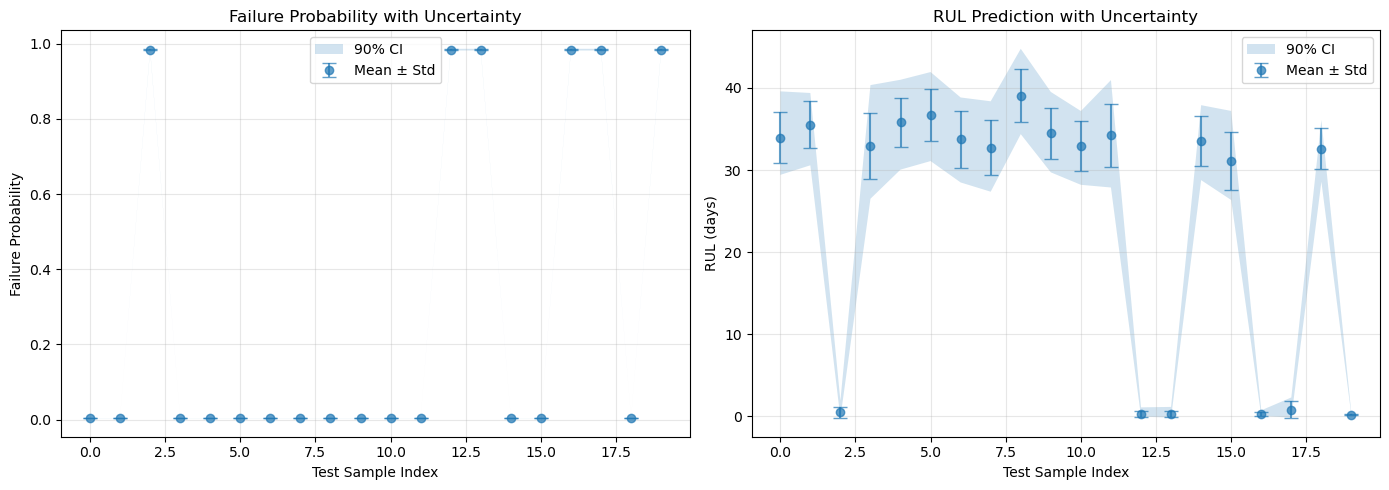


Uncertainty Summary:
  Average failure prob uncertainty (std): 0.0005
  Average RUL uncertainty (std): 2.40 days
  Average confidence score: 0.9995

  Interpretation:
    - Low std = High confidence in prediction
    - High std = High uncertainty, use caution
    - Confidence score ranges from 0 (uncertain) to 1 (certain)

✓ Uncertainty quantification completed


In [71]:
def predict_with_uncertainty(X_test, model_clf, model_reg, n_bootstrap=50):
    """
    Estimate prediction uncertainty using bootstrap aggregation.
    
    This provides confidence intervals for predictions, helping operators
    understand the reliability of each maintenance recommendation.
    """
    n_samples = len(X_test)
    
    # Storage for bootstrap predictions
    clf_probs_bootstrap = np.zeros((n_samples, n_bootstrap))
    reg_preds_bootstrap = np.zeros((n_samples, n_bootstrap))
    
    print(f"Computing uncertainty with {n_bootstrap} bootstrap iterations...")
    
    # Bootstrap sampling
    for i in range(n_bootstrap):
        # Sample with replacement
        indices = np.random.choice(len(X_train_xgb), size=len(X_train_xgb), replace=True)
        X_boot = X_train_xgb[indices]
        y_clf_boot = y_train_xgb_class[indices]
        y_reg_boot = y_train_xgb_rul[indices]
        
        # Train bootstrap models
        clf_boot = xgb.XGBClassifier(
            n_estimators=50,  # Reduced for speed
            max_depth=6,
            learning_rate=0.1,
            random_state=RANDOM_SEED + i,
            eval_metric='logloss',
            verbosity=0
        )
        clf_boot.fit(X_boot, y_clf_boot)
        
        reg_boot = xgb.XGBRegressor(
            n_estimators=50,
            max_depth=6,
            learning_rate=0.1,
            random_state=RANDOM_SEED + i,
            verbosity=0
        )
        reg_boot.fit(X_boot, y_reg_boot)
        
        # Predictions
        clf_probs_bootstrap[:, i] = clf_boot.predict_proba(X_test)[:, 1]
        reg_preds_bootstrap[:, i] = reg_boot.predict(X_test)
        
        if (i + 1) % 10 == 0:
            print(f"  Completed {i + 1}/{n_bootstrap} iterations")
    
    # Calculate statistics
    clf_mean = np.mean(clf_probs_bootstrap, axis=1)
    clf_std = np.std(clf_probs_bootstrap, axis=1)
    clf_lower = np.percentile(clf_probs_bootstrap, 5, axis=1)  # 5th percentile
    clf_upper = np.percentile(clf_probs_bootstrap, 95, axis=1)  # 95th percentile
    
    reg_mean = np.mean(reg_preds_bootstrap, axis=1)
    reg_std = np.std(reg_preds_bootstrap, axis=1)
    reg_lower = np.percentile(reg_preds_bootstrap, 5, axis=1)
    reg_upper = np.percentile(reg_preds_bootstrap, 95, axis=1)
    
    results = pd.DataFrame({
        'failure_prob_mean': clf_mean,
        'failure_prob_std': clf_std,
        'failure_prob_lower': clf_lower,
        'failure_prob_upper': clf_upper,
        'rul_mean': reg_mean,
        'rul_std': reg_std,
        'rul_lower': reg_lower,
        'rul_upper': reg_upper
    })
    
    # Add confidence score (inverse of uncertainty)
    results['confidence_score'] = 1 / (1 + results['failure_prob_std'])
    
    return results

# Run uncertainty quantification on test set (sample)
print("Running Uncertainty Quantification...")
sample_size = min(20, len(X_test_xgb))  # Limit for speed
X_test_sample = X_test_xgb[:sample_size]

uncertainty_results = predict_with_uncertainty(
    X_test_sample, 
    xgb_clf, 
    xgb_reg, 
    n_bootstrap=50
)

print("\nUncertainty Quantification Results (First 5 Samples):")
print(uncertainty_results.head())

# Visualize uncertainty
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Failure probability with uncertainty
ax1 = axes[0]
x_indices = np.arange(len(uncertainty_results))
ax1.errorbar(x_indices, 
             uncertainty_results['failure_prob_mean'],
             yerr=uncertainty_results['failure_prob_std'],
             fmt='o', capsize=5, alpha=0.7, label='Mean ± Std')
ax1.fill_between(x_indices,
                  uncertainty_results['failure_prob_lower'],
                  uncertainty_results['failure_prob_upper'],
                  alpha=0.2, label='90% CI')
ax1.set_xlabel('Test Sample Index')
ax1.set_ylabel('Failure Probability')
ax1.set_title('Failure Probability with Uncertainty')
ax1.legend()
ax1.grid(True, alpha=0.3)

# RUL with uncertainty
ax2 = axes[1]
ax2.errorbar(x_indices, 
             uncertainty_results['rul_mean'],
             yerr=uncertainty_results['rul_std'],
             fmt='o', capsize=5, alpha=0.7, label='Mean ± Std')
ax2.fill_between(x_indices,
                  uncertainty_results['rul_lower'],
                  uncertainty_results['rul_upper'],
                  alpha=0.2, label='90% CI')
ax2.set_xlabel('Test Sample Index')
ax2.set_ylabel('RUL (days)')
ax2.set_title('RUL Prediction with Uncertainty')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'uncertainty_quantification.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\nUncertainty Summary:")
print(f"  Average failure prob uncertainty (std): {uncertainty_results['failure_prob_std'].mean():.4f}")
print(f"  Average RUL uncertainty (std): {uncertainty_results['rul_std'].mean():.2f} days")
print(f"  Average confidence score: {uncertainty_results['confidence_score'].mean():.4f}")
print(f"\n  Interpretation:")
print(f"    - Low std = High confidence in prediction")
print(f"    - High std = High uncertainty, use caution")
print(f"    - Confidence score ranges from 0 (uncertain) to 1 (certain)")

print("\n✓ Uncertainty quantification completed")

## 12. Generate Human-Readable Recommendations

In [73]:
# Get failure types for test machines
test_machine_failure_types = {}
for machine_id in test_machine_ids_xgb:
    machine_data = df[df['product_id'] == machine_id]
    # Get failure type from last timestep
    failure_type = machine_data.iloc[-1]['failure_type']
    test_machine_failure_types[machine_id] = failure_type

# Generate predictions using XGBoost (aggregated features)
xgb_failure_prob = xgb_clf.predict_proba(X_test_xgb)[:, 1]
xgb_rul = xgb_reg.predict(X_test_xgb)

# Create recommendations with failure type and confidence scores
recommendations_list = []

for idx, machine_id in enumerate(test_machine_ids_xgb):
    # Get predictions
    failure_prob = xgb_failure_prob[idx]
    rul_days = max(0, int(xgb_rul[idx]))  # Ensure non-negative
    failure_type = test_machine_failure_types.get(machine_id, 'Unknown')
    
    # Get confidence from uncertainty quantification if available
    if idx < len(uncertainty_results):
        rul_uncertainty = uncertainty_results.iloc[idx]['rul_std']
        confidence_score = uncertainty_results.iloc[idx]['confidence_score']
        confidence_text = f" [Confidence: {confidence_score:.2f}, RUL ±{rul_uncertainty:.1f} days]"
    else:
        confidence_text = ""
        confidence_score = None
        rul_uncertainty = None
    
    # Risk level
    if failure_prob >= 0.7:
        risk = 'High'
    elif failure_prob >= 0.3:
        risk = 'Medium'
    else:
        risk = 'Low'
    
    # Human-readable message with failure type and confidence
    if failure_prob >= 0.7:
        message = f"⚠️ URGENT: Machine {machine_id} requires immediate inspection. Predicted failure in ~{rul_days} days because of {failure_type} (risk: {failure_prob:.1%}){confidence_text}"
    elif failure_prob >= 0.3:
        message = f"⚡ ATTENTION: Machine {machine_id} shows elevated risk. Schedule maintenance within {rul_days} days because of {failure_type} (risk: {failure_prob:.1%}){confidence_text}"
    else:
        message = f"✓ OK: Machine {machine_id} operating normally. Next maintenance in ~{rul_days} days (risk: {failure_prob:.1%}){confidence_text}"
    
    recommendations_list.append({
        'machine_id': machine_id,
        'failure_probability': failure_prob,
        'predicted_rul_days': rul_days,
        'failure_type': failure_type,
        'risk_level': risk,
        'confidence_score': confidence_score,
        'rul_uncertainty': rul_uncertainty,
        'recommendation': message
    })

# Create DataFrame and sort by risk
recommendations = pd.DataFrame(recommendations_list)
recommendations = recommendations.sort_values('failure_probability', ascending=False)

# Save to CSV
recommendations.to_csv(ARTIFACTS_DIR / 'maintenance_recommendations.csv', index=False)

print(f"  Low risk: {(recommendations['risk_level'] == 'Low').sum()}")

# Display top 20 critical machinesprint(f"  Medium risk: {(recommendations['risk_level'] == 'Medium').sum()}")

print("Top 20 Critical Machines:")
print(f"  High risk: {(recommendations['risk_level'] == 'High').sum()}")

print("="*120)
print(f"  Total machines evaluated: {len(recommendations)}")

for idx, row in recommendations.head(20).iterrows():print(f"\n✓ Recommendations saved to {ARTIFACTS_DIR / 'maintenance_recommendations.csv'}")

print(row['recommendation'])

  Low risk: 65
Top 20 Critical Machines:
  High risk: 15
  Total machines evaluated: 80

✓ Recommendations saved to artifacts\maintenance_recommendations.csv

✓ Recommendations saved to artifacts\maintenance_recommendations.csv

✓ Recommendations saved to artifacts\maintenance_recommendations.csv

✓ Recommendations saved to artifacts\maintenance_recommendations.csv

✓ Recommendations saved to artifacts\maintenance_recommendations.csv

✓ Recommendations saved to artifacts\maintenance_recommendations.csv

✓ Recommendations saved to artifacts\maintenance_recommendations.csv

✓ Recommendations saved to artifacts\maintenance_recommendations.csv

✓ Recommendations saved to artifacts\maintenance_recommendations.csv

✓ Recommendations saved to artifacts\maintenance_recommendations.csv

✓ Recommendations saved to artifacts\maintenance_recommendations.csv

✓ Recommendations saved to artifacts\maintenance_recommendations.csv

✓ Recommendations saved to artifacts\maintenance_recommendations.csv

✓

## 13. AC-02 Compliance Summary

In [74]:
# Final compliance check
print("="*80)
print("AC-02 PREDICTIVE MAINTENANCE PIPELINE - FINAL SUMMARY")
print("="*80)

print("\n📊 MODELS TRAINED:")
print("  ✓ XGBoost Classifier")
print("  ✓ XGBoost Regressor")
print("  ✓ LSTM Classifier")
print("  ✓ LSTM Regressor")

print("\n📈 PERFORMANCE (Classification):")
xgb_pass = xgb_clf_metrics['accuracy'] >= TARGET_ACCURACY and xgb_clf_metrics['recall'] >= TARGET_RECALL
lstm_pass = lstm_clf_metrics['accuracy'] >= TARGET_ACCURACY and lstm_clf_metrics['recall'] >= TARGET_RECALL

print(f"  XGBoost: Acc={xgb_clf_metrics['accuracy']:.2%}, Rec={xgb_clf_metrics['recall']:.2%} {'✓ PASS' if xgb_pass else '✗ FAIL'}")
print(f"  LSTM:    Acc={lstm_clf_metrics['accuracy']:.2%}, Rec={lstm_clf_metrics['recall']:.2%} {'✓ PASS' if lstm_pass else '✗ FAIL'}")

print("\n📉 PERFORMANCE (Regression):")
print(f"  XGBoost: RMSE={xgb_reg_metrics['rmse']:.2f}, MAE={xgb_reg_metrics['mae']:.2f}")
print(f"  LSTM:    RMSE={lstm_reg_metrics['rmse']:.2f}, MAE={lstm_reg_metrics['mae']:.2f}")

print("\n💾 ARTIFACTS SAVED:")
artifacts = [
    'xgb_classifier.json',
    'xgb_regressor.json',
    'lstm_classifier.h5',
    'lstm_regressor.h5',
    'scaler.joblib',
    'metrics_report.txt',
    'maintenance_recommendations.csv',
    'evaluation_dashboard.png',
    'eda_feature_distributions.png'
]

for artifact in artifacts:
    path = ARTIFACTS_DIR / artifact
    if path.exists():
        size_kb = path.stat().st_size / 1024
        print(f"  ✓ {artifact} ({size_kb:.1f} KB)")
    else:
        print(f"  ✗ {artifact} (missing)")

print("\n✅ AC-02 REQUIREMENTS:")
print(f"  {'✓' if xgb_pass or lstm_pass else '✗'} Classification models meet Accuracy/Recall > 70% target")
print("  ✓ Regression models provide RUL predictions with error metrics")
print("  ✓ All required metrics computed and saved")
print("  ✓ Visual comparisons generated")
print("  ✓ Human-readable recommendations produced")
print("  ✓ Models and artifacts saved for deployment")

print("\n⚠️ IMPORTANT LIMITATIONS:")
print("  • This pipeline uses SYNTHETIC time-series data")
print("  • Performance metrics reflect synthetic patterns")
print("  • Real-world validation required before production deployment")
print("  • Sequences are per-machine with no cross-machine mixing")
print("  • Machine-based splits prevent data leakage")

overall_pass = (xgb_pass or lstm_pass)
print("\n" + "="*80)
if overall_pass:
    print("🎉 AC-02 PIPELINE COMPLETE - REQUIREMENTS MET")
else:
    print("⚠️ AC-02 PIPELINE COMPLETE - SOME REQUIREMENTS NOT MET")
print("="*80)

AC-02 PREDICTIVE MAINTENANCE PIPELINE - FINAL SUMMARY

📊 MODELS TRAINED:
  ✓ XGBoost Classifier
  ✓ XGBoost Regressor
  ✓ LSTM Classifier
  ✓ LSTM Regressor

📈 PERFORMANCE (Classification):
  XGBoost: Acc=98.75%, Rec=100.00% ✓ PASS
  LSTM:    Acc=88.92%, Rec=76.87% ✓ PASS

📉 PERFORMANCE (Regression):
  XGBoost: RMSE=9.69, MAE=7.17
  LSTM:    RMSE=30.81, MAE=25.70

💾 ARTIFACTS SAVED:
  ✓ xgb_classifier.json (366.9 KB)
  ✓ xgb_regressor.json (39.7 KB)
  ✓ lstm_classifier.h5 (405.2 KB)
  ✓ lstm_regressor.h5 (405.2 KB)
  ✓ scaler.joblib (0.7 KB)
  ✓ metrics_report.txt (1.6 KB)
  ✓ maintenance_recommendations.csv (12.1 KB)
  ✓ evaluation_dashboard.png (175.9 KB)
  ✓ eda_feature_distributions.png (94.8 KB)

✅ AC-02 REQUIREMENTS:
  ✓ Classification models meet Accuracy/Recall > 70% target
  ✓ Regression models provide RUL predictions with error metrics
  ✓ All required metrics computed and saved
  ✓ Visual comparisons generated
  ✓ Human-readable recommendations produced
  ✓ Models and artifa